In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import csv
import os

def upsampling(data, target_length):
    """
    Upsample a 1D numpy array to the desired target length using linear interpolation.
    """
    original_length = len(data)
    original_indices = np.linspace(0, original_length - 1, original_length)
    new_indices = np.linspace(0, original_length - 1, target_length)
    return np.interp(new_indices, original_indices, data)

def extract_gc(GRFdata, threshold):
    """
    Extract heel strike indices and form gait cycle segments from GRF data.
    """
    grf = GRFdata.copy()
    # Create binary GRF signal based on threshold
    bi_grf = np.where(grf < threshold, 0, 1)
    diff_grf = np.diff(bi_grf)
    # Find indices where the signal goes from 0 to 1
    heelstrike_index = np.where(diff_grf == 1)[0] + 1
    if len(heelstrike_index) >= 2:
        # Each gait cycle: start at one heel strike and end just before the next
        gait_cycles = np.column_stack((heelstrike_index[:-1], heelstrike_index[1:] - 1))
    else:
        gait_cycles = np.empty((0, 2))
        print("Warning: Not enough gait cycles detected.")
    return heelstrike_index, gait_cycles

def segmenting(data, gait_cycles, target_length=100, number_of_cycles=0):
    """
    Segment the data based on gait cycle indices and return all segments and their average.
    """
    segments = []
    
    if number_of_cycles == 0:
        for start, end in gait_cycles:
            segment = data[start:end+1]
            segment_upsampled = upsampling(segment, target_length)
            segments.append(segment_upsampled)
        # print('number of gait cycles: ',np.shape(segments))
    else:
        for i in range(number_of_cycles):
            start, end = gait_cycles[i]
            segment = data[start:end+1]
            segment_upsampled = upsampling(segment, target_length)
            segments.append(segment_upsampled)
        # print('number of gait cycles: ',np.shape(segments))

    segments = np.array(segments).T  # shape: (target_length, number of cycles)
    avg_data = np.mean(segments, axis=1)
    std_data = np.std(segments, axis=1)
    return segments, avg_data, std_data

def segmenting_motor_peak(data, peak_indices, target_length=100):
    """
    Segment the data based on gait cycle indices and return all segments and their average.
    data: numpy array of shape (n_samples, n_features)
    peak_indices: numpy array of shape (n_peak) with start and end indices of each gait cycle
    target_length: desired length of each segment after upsampling
    """
    if data.ndim == 1:
        data = data.reshape(-1, 1)  # Convert to 2D array with one feature

    segments = np.zeros((len(peak_indices) - 1, data.shape[1], target_length))

    for n, (start, end) in enumerate(zip(peak_indices[:-1], peak_indices[1:])):
        for i in range(data.shape[1]):
            segment = data[start:end+1, i]
            segment_upsampled = upsampling(segment, target_length)
            segments[n, i, :] = segment_upsampled

    avg_data = np.mean(segments, axis=0)
    std_data = np.std(segments, axis=0)

    return segments, avg_data, std_data # (number_of_cycles, n_features, target_length)

def load_vicon_data(filename):
    # Load CSV files (adjust file paths as needed)
    with open(filename, 'r') as file:
        reader = csv.reader(file)
        data = []
        max_length = 0
        for row in reader:
            try:
                # Convert empty strings to '0' and then convert to float
                numeric_row = [float(x) if x != '' else 0 for x in row]
                if all(x == 0 for x in numeric_row):    continue
                data.append(numeric_row)
                if len(numeric_row) > max_length:   max_length = len(numeric_row)
            except ValueError:
                # Skip rows that cannot be converted to float
                continue
        # Ensure all rows have the same length
        for i in range(len(data)):
            if len(data[i]) < max_length:
                data[i] += [0] * (max_length - len(data[i]))
        numeric_data = np.array(data, dtype=float)
    return numeric_data

def process_data(data, data_motor, trim_point_sec, trial_length_sec, mass_kg, RD=False, number_of_cycles=0):
    """
    Process the motion capture data to compute average joint kinematics and kinetics.
    """
    # Convert NumPy array to DataFrame if necessary
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data)

    ######################################
    ########## 1. Load the data ##########
    ######################################

    # Adjusted column indices (0-indexed) corresponding to the MATLAB code
    if RD:
        GRF_columns = [13, 4]  # Right and Left GRF vertical components
    else:
        GRF_columns = [4, 13]
    ankle_moment_l_columns = [2, 3, 4]
    hip_moment_l_columns = [5, 6, 7]
    knee_moment_l_columns = [8, 9, 10]
    ankle_moment_r_columns = [50, 51, 52]
    hip_moment_r_columns = [53, 54, 55]
    knee_moment_r_columns = [56, 57, 58]
    ankle_angle_l_columns = [11, 12, 13]      # w/ kinetics information
    hip_angle_l_columns = [26, 27, 28]
    knee_angle_l_columns = [29, 30, 31]
    ankle_angle_r_columns = [59, 60, 61]
    hip_angle_r_columns = [74, 75, 76]
    knee_angle_r_columns = [77, 78, 79]
    # ankle_angle_l_columns = [2, 3, 4]       # w/o kinetics information
    # hip_angle_l_columns = [17, 18, 19]
    # knee_angle_l_columns = [20, 21, 22]
    # ankle_angle_r_columns = [41, 42, 43]
    # hip_angle_r_columns = [56, 57, 58]
    # knee_angle_r_columns = [59, 60, 61]
    
    # # GRF Data processing (Note: Adjusting for 0-indexing)
    GRF_data = data.iloc[1:trial_length_sec * 1000 + 1, GRF_columns].to_numpy()
    GRF_r = -GRF_data[:, 0]
    GRF_l = -GRF_data[:, 1]
    GRF_l = GRF_l[trim_point_sec * 1000:]
    GRF_r = GRF_r[trim_point_sec * 1000:]

    start_row = trial_length_sec * 1000 + 2

    # Hip Data
    hip_moment_l_data = data.iloc[start_row:, hip_moment_l_columns].to_numpy().astype(float) * 0.001
    hip_moment_r_data = data.iloc[start_row:, hip_moment_r_columns].to_numpy().astype(float) * 0.001
    hip_moment_l = hip_moment_l_data[1:-1, 1] # Take y-axis for hip flexion
    hip_moment_r = hip_moment_r_data[1:-1, 1] # Take y-axis for hip flexion
    hip_moment_l = hip_moment_l[trim_point_sec:]
    hip_moment_r = hip_moment_r[trim_point_sec:]
    
    hip_angle_l_data = data.iloc[start_row:, hip_angle_l_columns].to_numpy().astype(float) # * np.pi / 180
    hip_angle_r_data = data.iloc[start_row:, hip_angle_r_columns].to_numpy().astype(float) # * np.pi / 180
    hip_angle_l = hip_angle_l_data[trim_point_sec:, :]
    hip_angle_r = hip_angle_r_data[trim_point_sec:, :]

    # Knee Data
    knee_moment_l_data = data.iloc[start_row:, knee_moment_l_columns].to_numpy().astype(float) * 0.001
    knee_moment_r_data = data.iloc[start_row:, knee_moment_r_columns].to_numpy().astype(float) * 0.001
    knee_moment_l = knee_moment_l_data[1:-1, 1] # Take y-axis for knee flexion
    knee_moment_r = knee_moment_r_data[1:-1, 1] # Take y-axis for knee flexion
    knee_moment_l = knee_moment_l[trim_point_sec:]
    knee_moment_r = knee_moment_r[trim_point_sec:]
    
    knee_angle_l_data = data.iloc[start_row:, knee_angle_l_columns].to_numpy().astype(float) # * np.pi / 180
    knee_angle_r_data = data.iloc[start_row:, knee_angle_r_columns].to_numpy().astype(float) # * np.pi / 180
    knee_angle_l = knee_angle_l_data[trim_point_sec:, :]
    knee_angle_r = knee_angle_r_data[trim_point_sec:, :]

    # Ankle
    ankle_moment_l_data = data.iloc[start_row:, ankle_moment_l_columns].to_numpy().astype(float) * 0.001
    ankle_moment_r_data = data.iloc[start_row:, ankle_moment_r_columns].to_numpy().astype(float) * 0.001
    ankle_moment_l = ankle_moment_l_data[1:-1, 2] # Take z-axis for ankle flexion
    ankle_moment_r = ankle_moment_r_data[1:-1, 2] # Take z-axis for ankle flexion
    ankle_moment_l = ankle_moment_l[trim_point_sec:]
    ankle_moment_r = ankle_moment_r[trim_point_sec:]

    ankle_angle_l_data = data.iloc[start_row:, ankle_angle_l_columns].to_numpy().astype(float) # * np.pi / 180
    ankle_angle_r_data = data.iloc[start_row:, ankle_angle_r_columns].to_numpy().astype(float) # * np.pi / 180
    ankle_angle_l = ankle_angle_l_data[trim_point_sec:, :]
    ankle_angle_r = ankle_angle_r_data[trim_point_sec:, :]
    
    #################################################
    ######### 2. Filter and calculate power #########
    #################################################

    fs = 100
    lpf_order = 4
    fc = 6
    Wn = fc / (fs / 2)
    b, a = butter(lpf_order, Wn, btype='low')

    hip_moment_r_filt = filtfilt(b, a, hip_moment_r)
    hip_moment_l_filt = filtfilt(b, a, hip_moment_l)
    knee_moment_r_filt = filtfilt(b, a, knee_moment_r)
    knee_moment_l_filt = filtfilt(b, a, knee_moment_l)
    ankle_moment_r_filt = filtfilt(b, a, ankle_moment_r)
    ankle_moment_l_filt = filtfilt(b, a, ankle_moment_l)

    dt = 1 / fs

    # For hip
    hip_theta_l = hip_angle_l[:, 0]
    hip_theta_r = hip_angle_r[:, 0]
    hip_omega_diff_l = np.diff(hip_theta_l) / dt
    hip_omega_diff_r = np.diff(hip_theta_r) / dt
    hip_power_r = hip_moment_r_filt * hip_omega_diff_r[1:]
    hip_power_l = hip_moment_l_filt * hip_omega_diff_l[1:]

    # For knee
    knee_theta_l = knee_angle_l[:, 0]
    knee_theta_r = knee_angle_r[:, 0]
    knee_omega_diff_l = np.diff(knee_theta_l) / dt
    knee_omega_diff_r = np.diff(knee_theta_r) / dt
    knee_power_r = knee_moment_r_filt * knee_omega_diff_r[1:]
    knee_power_l = knee_moment_l_filt * knee_omega_diff_l[1:]

    # Angular velocity and joint power for ankle
    ankle_theta_l = ankle_angle_l[:, 0]
    ankle_theta_r = ankle_angle_r[:, 0]
    ankle_omega_diff_l = np.diff(ankle_theta_l) / dt
    ankle_omega_diff_r = np.diff(ankle_theta_r) / dt
    ankle_power_r = ankle_moment_r_filt * ankle_omega_diff_r[1:]
    ankle_power_l = ankle_moment_l_filt * ankle_omega_diff_l[1:]
    
    ##################################################################
    ######### 3. Upsample data to sync with force plate data #########
    ##################################################################

    # # Upsampling from 100Hz to 1000Hz
    # hip_angle_l = upsampling(hip_angle_l[:, 0], len(hip_angle_l[:, 0]) * 10)
    # hip_angle_r = upsampling(hip_angle_r[:, 0], len(hip_angle_r[:, 0]) * 10)
    # hip_moment_r_up = upsampling(hip_moment_r_filt, len(hip_moment_r_filt) * 10)
    # hip_moment_l_up = upsampling(hip_moment_l_filt, len(hip_moment_l_filt) * 10)
    # hip_power_r_up = upsampling(hip_power_r, len(hip_power_r) * 10)
    # hip_power_l_up = upsampling(hip_power_l, len(hip_power_l) * 10)
    
    # knee_angle_l = upsampling(knee_angle_l[:, 0], len(knee_angle_l[:, 0]) * 10)
    # knee_angle_r = upsampling(knee_angle_r[:, 0], len(knee_angle_r[:, 0]) * 10)
    # knee_moment_r_up = upsampling(knee_moment_r_filt, len(knee_moment_r_filt) * 10)
    # knee_moment_l_up = upsampling(knee_moment_l_filt, len(knee_moment_l_filt) * 10)
    # knee_power_r_up = upsampling(knee_power_r, len(knee_power_r) * 10)
    # knee_power_l_up = upsampling(knee_power_l, len(knee_power_l) * 10)

    # ankle_angle_l = upsampling(ankle_angle_l[:, 0], len(ankle_angle_l[:, 0]) * 10)
    # ankle_angle_r = upsampling(ankle_angle_r[:, 0], len(ankle_angle_r[:, 0]) * 10)
    # ankle_moment_r_up = upsampling(ankle_moment_r_filt, len(ankle_moment_r_filt) * 10)
    # ankle_moment_l_up = upsampling(ankle_moment_l_filt, len(ankle_moment_l_filt) * 10)
    # ankle_power_r_up = upsampling(ankle_power_r, len(ankle_power_r) * 10)
    # ankle_power_l_up = upsampling(ankle_power_l, len(ankle_power_l) * 10)
    
    mass_N = mass_kg * 9.81665
    threshold = mass_N * 0.1
    # heelstrike_r, gait_cycles_r = extract_gc(GRF_r, threshold)
    # heelstrike_l, gait_cycles_l = extract_gc(GRF_l, threshold)

    peak_indices_r, _ = find_peaks(data_motor['mtr_pos_R'], height=None, distance=80, prominence=10)
    peak_indices_l, _ = find_peaks(-data_motor['mtr_pos_L'], height=None, distance=80, prominence=10)
    
    # print('number of gait cycles (left): ', np.shape(gait_cycles_l)[0])
    # print('number of gait cycles (right): ', np.shape(gait_cycles_r)[0])

    ###################################
    ######### 4. Segment data #########
    ###################################
    
    # Note: Right- and left-side moments' signs are negative in the vicon data. We flip the sign of the left side to match the right side.
    _l, avg_hip_angle_l, std_hip_angle_l = segmenting_motor_peak(hip_angle_l, peak_indices_l)
    _r, avg_hip_angle_r, std_hip_angle_r = segmenting_motor_peak(hip_angle_r, peak_indices_r)
    avg_hip_angle = np.mean(np.vstack([avg_hip_angle_l, avg_hip_angle_r]), axis=0)
    std_hip_angle = np.std(np.vstack([_l, _r]), axis=0)

    _l, avg_hip_moment_l, std_hip_moment_l = segmenting_motor_peak(-hip_moment_l_filt, peak_indices_l)
    _r, avg_hip_moment_r, std_hip_moment_r = segmenting_motor_peak(hip_moment_r_filt, peak_indices_r)
    avg_hip_moment = np.mean(np.vstack([avg_hip_moment_l, avg_hip_moment_r]), axis=0)
    std_hip_moment = np.std(np.vstack([_l, _r]), axis=0)

    _l, avg_hip_power_l, std_hip_power_l = segmenting_motor_peak(-hip_power_l, peak_indices_l)
    _r, avg_hip_power_r, std_hip_power_r = segmenting_motor_peak(hip_power_r, peak_indices_r)
    avg_hip_power = np.mean(np.vstack([avg_hip_power_l, avg_hip_power_r]), axis=0)
    std_hip_power = np.std(np.vstack([_l, _r]), axis=0)

    _l, avg_knee_angle_l, std_knee_angle_l = segmenting_motor_peak(knee_angle_l, peak_indices_l)
    _r, avg_knee_angle_r, std_knee_angle_r = segmenting_motor_peak(knee_angle_r, peak_indices_r)
    avg_knee_angle = np.mean(np.vstack([avg_knee_angle_l, avg_knee_angle_r]), axis=0)
    std_knee_angle = np.std(np.vstack([_l, _r]), axis=0)

    _l, avg_knee_moment_l, std_knee_moment_l = segmenting_motor_peak(-knee_moment_l_filt, peak_indices_l)
    _r, avg_knee_moment_r, std_knee_moment_r = segmenting_motor_peak(knee_moment_r_filt, peak_indices_r)
    avg_knee_moment = np.mean(np.vstack([avg_knee_moment_l, avg_knee_moment_r]), axis=0)
    std_knee_moment = np.std(np.vstack([_l, _r]), axis=0)

    _l, avg_knee_power_l, std_knee_power_l = segmenting_motor_peak(-knee_power_l, peak_indices_l)
    _r, avg_knee_power_r, std_knee_power_r = segmenting_motor_peak(knee_power_r, peak_indices_r)
    avg_knee_power = np.mean(np.vstack([avg_knee_power_l, avg_knee_power_r]), axis=0)
    std_knee_power = np.std(np.vstack([_l, _r]), axis=0)

    _l, avg_ankle_angle_l, std_ankle_angle_l = segmenting_motor_peak(ankle_angle_l, peak_indices_l)
    _r, avg_ankle_angle_r, std_ankle_angle_r = segmenting_motor_peak(ankle_angle_r, peak_indices_r)
    avg_ankle_angle = np.mean(np.vstack([avg_ankle_angle_l, avg_ankle_angle_r]), axis=0)
    std_ankle_angle = np.std(np.vstack([_l, _r]), axis=0)

    _l, avg_ankle_moment_l, std_ankle_moment_l = segmenting_motor_peak(-ankle_moment_l_filt, peak_indices_l)
    _r, avg_ankle_moment_r, std_ankle_moment_r = segmenting_motor_peak(ankle_moment_r_filt, peak_indices_r)
    avg_ankle_moment = np.mean(np.vstack([avg_ankle_moment_l, avg_ankle_moment_r]), axis=0)
    std_ankle_moment = np.std(np.vstack([_l, _r]), axis=0)

    _l, avg_ankle_power_l, std_ankle_power_l = segmenting_motor_peak(-ankle_power_l, peak_indices_l)
    _r, avg_ankle_power_r, std_ankle_power_r = segmenting_motor_peak(ankle_power_r, peak_indices_r)
    avg_ankle_power = np.mean(np.vstack([avg_ankle_power_l, avg_ankle_power_r]), axis=0)
    std_ankle_power = np.std(np.vstack([_l, _r]), axis=0)
    
    return ([avg_hip_angle_l, std_hip_angle_l, avg_hip_angle_r, std_hip_angle_r, avg_hip_angle, std_hip_angle],
            [avg_hip_moment_l, std_hip_moment_l, avg_hip_moment_r, std_hip_moment_r, avg_hip_moment, std_hip_moment],
            [avg_hip_power_l, std_hip_power_l, avg_hip_power_r, std_hip_power_r, avg_hip_power, std_hip_power],
            [avg_knee_angle_l, std_knee_angle_l, avg_knee_angle_r, std_knee_angle_r, avg_knee_angle, std_knee_angle],
            [avg_knee_moment_l, std_knee_moment_l, avg_knee_moment_r, std_knee_moment_r, avg_knee_moment, std_knee_moment],
            [avg_knee_power_l, std_knee_power_l, avg_knee_power_r, std_knee_power_r, avg_knee_power, std_knee_power],
            [avg_ankle_angle_l, std_ankle_angle_l, avg_ankle_angle_r, std_ankle_angle_r, avg_ankle_angle, std_ankle_angle],
            [avg_ankle_moment_l, std_ankle_moment_l, avg_ankle_moment_r, std_ankle_moment_r, avg_ankle_moment, std_ankle_moment],
            [avg_ankle_power_l, std_ankle_power_l, avg_ankle_power_r, std_ankle_power_r, avg_ankle_power, std_ankle_power])

In [2]:
subjects = {'AB01_Jimin': 80,
            'AB02_Rajiv': 61,
            'AB03_Amy': 52,
            'AB04_Changseob': 72,
            'AB05_Maria': 57,
            'AB07_Leo': 74,
            'AB08_Adrian': 86,
            'AB11_Ryan': 72,
            'AB12_Ray': 79,
            'AB13_Hridayam': 75,
            'AB14_Evy': 68}

inclinations = ['RD_10deg', 'RD_5deg', 'LG', 'RA_5deg', 'RA_10deg']
speeds = ['0p2mps', '0p4mps', '0p6mps', '0p8mps', '1p0mps', '1p2mps', '1p4mps']
inclinations_unseen = ['RD_8p75deg', 'RD_7p5deg', 'RD_6p25deg', 'RD_3p75deg', 'RD_2p5deg', 'RD_1p25deg', 
                       'RA_1p25deg', 'RA_2p5deg', 'RA_3p75deg', 'RA_6p25deg', 'RA_7p5deg', 'RA_8p75deg']
speeds_unseen = ['0p25mps', '0p3mps', '0p35mps', '0p45mps', '0p5mps', '0p55mps', '0p65mps', '0p7mps', '0p75mps', 
                 '0p85mps', '0p9mps', '0p95mps', '1p05mps', '1p1mps', '1p15mps', '1p25mps', '1p3mps', '1p35mps']
inclinations_all = ['RD_10deg', 'RD_8p75deg', 'RD_7p5deg', 'RD_6p25deg', 'RD_5deg', 'RD_3p75deg', 'RD_2p5deg', 'RD_1p25deg', 'LG',
                    'RA_1p25deg', 'RA_2p5deg', 'RA_3p75deg', 'RA_5deg', 'RA_6p25deg', 'RA_7p5deg', 'RA_8p75deg', 'RA_10deg']
speeds_all = ['0p2mps', '0p25mps', '0p3mps', '0p35mps', '0p4mps', '0p45mps', '0p5mps', '0p55mps', '0p6mps', '0p65mps', '0p7mps', '0p75mps', 
             '0p8mps', '0p85mps', '0p9mps', '0p95mps', '1p0mps', '1p05mps', '1p1mps', '1p15mps', '1p2mps', '1p25mps', '1p3mps', '1p35mps', '1p4mps']

avg_hip_torque = {inc: {spd: None for spd in speeds_all} for inc in inclinations_all}

for inclination in inclinations:
    for speed in speeds:
        if inclination != 'LG' and speed not in ['0p4mps', '0p6mps', '0p8mps', '1p0mps']:
            continue
        if inclination == 'RD_10deg' and speed in ['0p4mps', '0p6mps']:
            continue
        print(f'Processing inclination: {inclination}, speed: {speed}')

        hip_torque_profile_per_subject = np.zeros((len(subjects), 100))  # 9 features: hip, knee, ankle angles and moments and powers

        for subject, mass_kg in subjects.items():
            # print(f'\tProcessing data for subject: {subject}')
            trim_point_sec = 0
            trial_length_sec = 29
            trials = os.listdir(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/{inclination}/{speed}')
            label_dir = f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/{inclination}/{speed}/{trials[0]}/Label'
            label_file = os.listdir(label_dir)
            raw_data = load_vicon_data(label_dir + '/' + label_file[0])

            motor_file = f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/{inclination}/{speed}/{trials[0]}/Input/motor_positions.csv'

            data_label = pd.DataFrame(raw_data)  # Convert to DataFrame before processing
            data_motor = pd.read_csv(motor_file)

            if 'RD' in inclination:
                results1 = process_data(data_label, data_motor, trim_point_sec, trial_length_sec, mass_kg, RD=True)
            else:
                results1 = process_data(data_label, data_motor, trim_point_sec, trial_length_sec, mass_kg, RD=False)
            ([avg_hip_angle_l, std_hip_angle_l, avg_hip_angle_r, std_hip_angle_r, avg_hip_angle, std_hip_angle],
            [avg_hip_moment_l, std_hip_moment_l, avg_hip_moment_r, std_hip_moment_r, avg_hip_moment, std_hip_moment],
            [avg_hip_power_l, std_hip_power_l, avg_hip_power_r, std_hip_power_r, avg_hip_power, std_hip_power], 
            [avg_knee_angle_l, std_knee_angle_l, avg_knee_angle_r, std_knee_angle_r, avg_knee_angle, std_knee_angle],
            [avg_knee_moment_l, std_knee_moment_l, avg_knee_moment_r, std_knee_moment_r, avg_knee_moment, std_knee_moment],
            [avg_knee_power_l, std_knee_power_l, avg_knee_power_r, std_knee_power_r, avg_knee_power, std_knee_power],
            [avg_ankle_angle_l, std_ankle_angle_l, avg_ankle_angle_r, std_ankle_angle_r, avg_ankle_angle, std_ankle_angle],
            [avg_ankle_moment_l, std_ankle_moment_l, avg_ankle_moment_r, std_ankle_moment_r, avg_ankle_moment, std_ankle_moment],
            [avg_ankle_power_l, std_ankle_power_l, avg_ankle_power_r, std_ankle_power_r, avg_ankle_power, std_ankle_power])\
                  = results1

            hip_torque_profile_per_subject[list(subjects.keys()).index(subject), :] = -avg_hip_moment # flexion positive

        avg_hip_torque[inclination][speed] = hip_torque_profile_per_subject.mean(axis=0)

Processing inclination: RD_10deg, speed: 0p8mps
Processing inclination: RD_10deg, speed: 1p0mps
Processing inclination: RD_5deg, speed: 0p4mps
Processing inclination: RD_5deg, speed: 0p6mps
Processing inclination: RD_5deg, speed: 0p8mps
Processing inclination: RD_5deg, speed: 1p0mps
Processing inclination: LG, speed: 0p2mps
Processing inclination: LG, speed: 0p4mps
Processing inclination: LG, speed: 0p6mps
Processing inclination: LG, speed: 0p8mps
Processing inclination: LG, speed: 1p0mps
Processing inclination: LG, speed: 1p2mps
Processing inclination: LG, speed: 1p4mps
Processing inclination: RA_5deg, speed: 0p4mps
Processing inclination: RA_5deg, speed: 0p6mps
Processing inclination: RA_5deg, speed: 0p8mps
Processing inclination: RA_5deg, speed: 1p0mps
Processing inclination: RA_10deg, speed: 0p4mps
Processing inclination: RA_10deg, speed: 0p6mps
Processing inclination: RA_10deg, speed: 0p8mps
Processing inclination: RA_10deg, speed: 1p0mps


0.569
-0.285


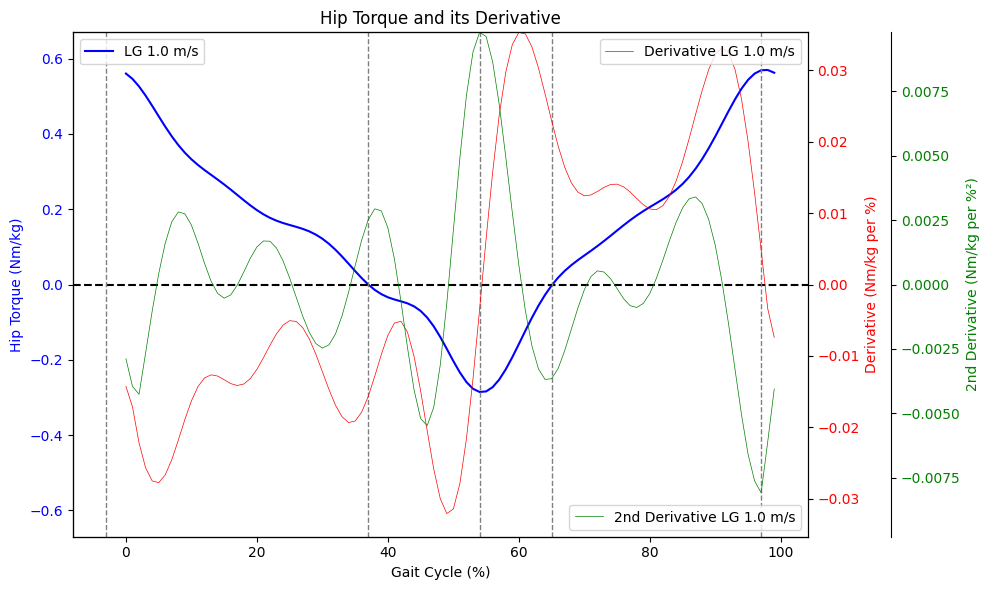

In [61]:
incline = 'RD_10deg'
speed = '1p0mps'

derivative = np.gradient(avg_hip_torque[incline][speed])
derivative_2nd = np.gradient(derivative)
plt.figure(figsize=(10, 6))

# Create first y-axis for the original data
ax1 = plt.gca()
ax1.plot(avg_hip_torque[incline][speed], label='LG 1.0 m/s', color='blue')
ax1.set_xlabel('Gait Cycle (%)')
ax1.set_ylabel('Hip Torque (Nm/kg)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Make y-axis symmetric
max_abs_orig = max(abs(avg_hip_torque[incline][speed].min()), abs(avg_hip_torque[incline][speed].max()))
ax1.set_ylim(-max_abs_orig-0.1, max_abs_orig+0.1)
ax1.axhline(y=0, color='black', linestyle='--')

ax1.axvline(x=-3, color='gray', linestyle='--', linewidth=1)
ax1.axvline(x=37, color='gray', linestyle='--', linewidth=1)
ax1.axvline(x=54, color='gray', linestyle='--', linewidth=1)
ax1.axvline(x=65, color='gray', linestyle='--', linewidth=1)
ax1.axvline(x=97, color='gray', linestyle='--', linewidth=1)
print(f'{avg_hip_torque[incline][speed][97]:.3f}')
print(f'{avg_hip_torque[incline][speed][54]:.3f}')

# Create second y-axis for the derivative
ax2 = ax1.twinx()
ax2.plot(derivative, label='Derivative LG 1.0 m/s', color='red', linewidth=0.5)
ax2.set_ylabel('Derivative (Nm/kg per %)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

# Make y-axis symmetric
max_abs = max(abs(derivative.min()), abs(derivative.max()))
ax2.set_ylim(-max_abs, max_abs)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset the third y-axis
ax3.plot(derivative_2nd, label='2nd Derivative LG 1.0 m/s', color='green', linewidth=0.5)
ax3.set_ylabel('2nd Derivative (Nm/kg per %²)', color='green')
ax3.tick_params(axis='y', labelcolor='green')
ax3.legend(loc='lower right')

# Make y-axis symmetric
max_abs_2nd = max(abs(derivative_2nd.min()), abs(derivative_2nd.max()))
ax3.set_ylim(-max_abs_2nd, max_abs_2nd)

plt.title('Hip Torque and its Derivative')
plt.tight_layout()
plt.show()

/tmp/ipykernel_152411/3279589150.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('copper', num_speeds)  # You can choose other colormaps like 'jet', 'plasma', etc.


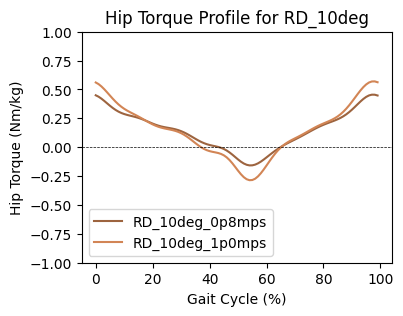

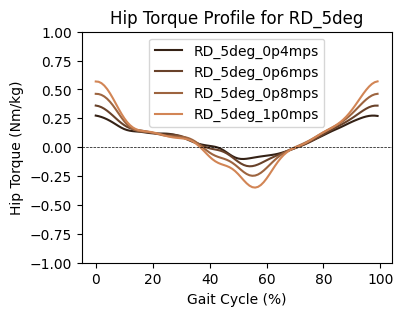

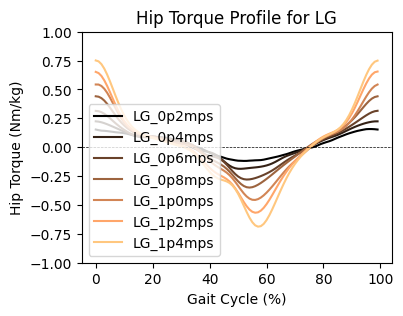

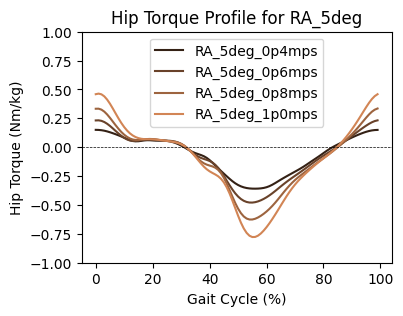

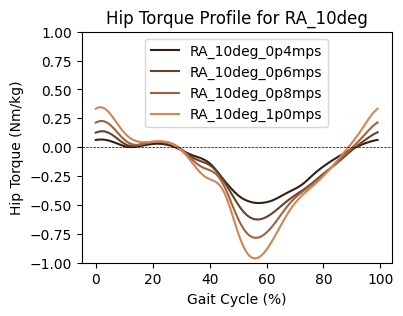

In [3]:
import matplotlib.cm as cm
num_speeds = len(speeds_all)
colormap = cm.get_cmap('copper', num_speeds)  # You can choose other colormaps like 'jet', 'plasma', etc.
speed_colors = {speeds_all[i]: colormap(i) for i in range(num_speeds)}

for inclination in inclinations:
    fig = plt.figure(figsize=(4, 3))
    for speed in speeds:
        if inclination != 'LG' and speed not in ['0p4mps', '0p6mps', '0p8mps', '1p0mps']:
            continue
        if inclination == 'RD_10deg' and speed in ['0p4mps', '0p6mps']:
            continue
        if 'RD' in inclination:
            plt.plot(avg_hip_torque[inclination][speed], label=f'{inclination}_{speed}', color=speed_colors[speed])
        else:
            plt.plot(avg_hip_torque[inclination][speed], label=f'{inclination}_{speed}', color=speed_colors[speed])
        plt.xlabel('Gait Cycle (%)')
        plt.ylabel('Hip Torque (Nm/kg)')
    plt.legend()
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.ylim(-1, 1)
    plt.title(f'Hip Torque Profile for {inclination}')
    plt.show()

RD_10deg
RD_5deg
LG
RA_5deg
RA_10deg


/tmp/ipykernel_838750/3070988792.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('copper', num_speeds)


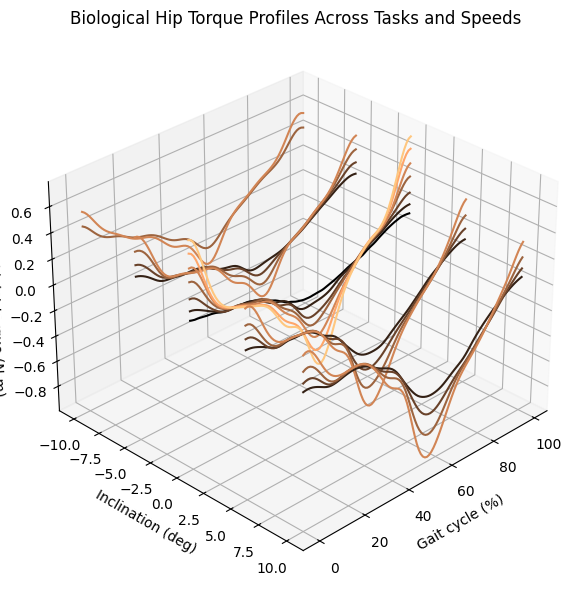

In [4]:
num_speeds = len(speeds_all)
colormap = cm.get_cmap('copper', num_speeds)
speed_colors = {}
for i in range(num_speeds):
    # Get RGBA tuple (0-1 range) and convert to RGB (0-255 range)
    rgba = colormap(i)
    speed_colors[speeds_all[i]] = rgba  # Store RGBA values directly

inclinations_num = [-10, -5, 0, 5, 10]

fig = plt.figure(figsize=(6, 6)) # Increased size from (6, 6) to (8, 8)
ax = fig.add_subplot(111, projection='3d')

for i, inclination in enumerate(inclinations):
    print(inclination)
    for speed in speeds:
        if avg_hip_torque[inclination][speed] is None:
            continue
        
        z = inclinations_num[i]
        
        x = np.arange(len(avg_hip_torque[inclination][speed]))
        y = avg_hip_torque[inclination][speed]
        
        # Create an array of z values for each point
        z_values = np.array([z] * len(x))
        
        # Get the color for the current speed
        color = speed_colors[speed]
        
        # Plot the data, interchanging y and z_values
        ax.plot(x, z_values, y, color=color, label=f'{inclination} - {speed}')

ax.set_xlabel('Gait cycle (%)')
ax.set_zlabel('Biological joint torque (N-m)') # interchanging y and z labels
ax.set_ylabel('Inclination (deg)') # interchanging y and z labels

# Optionally, create a legend (it might be too crowded)
# ax.legend()
ax.view_init(elev=30, azim=45)  # Adjust elevation and azimuth as needed
ax.invert_xaxis()

plt.title('Biological Hip Torque Profiles Across Tasks and Speeds')
plt.tight_layout()
plt.show()


# Interpolate Mid-tasks

/tmp/ipykernel_2227442/1889114751.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('gist_heat', num_speeds)  # You can choose other colormaps like 'jet', 'plasma', etc.


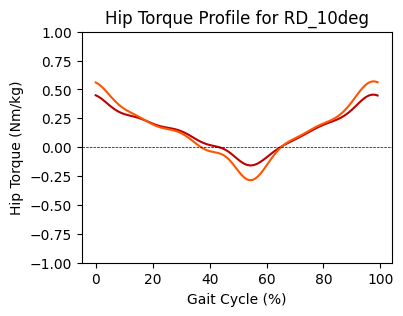

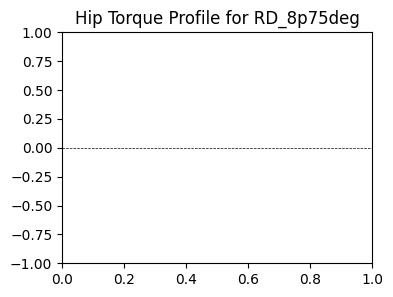

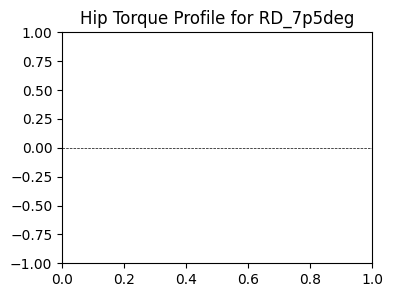

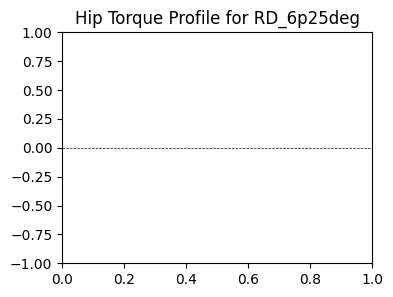

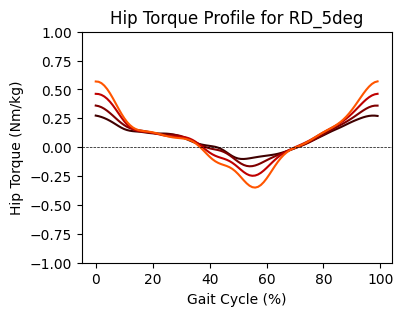

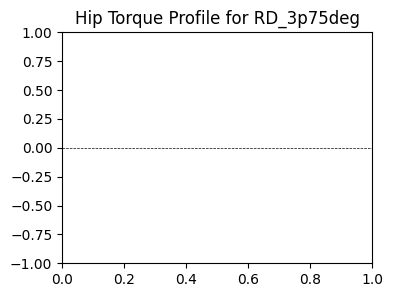

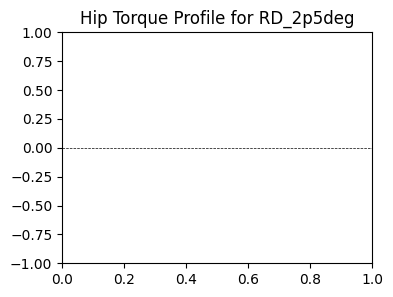

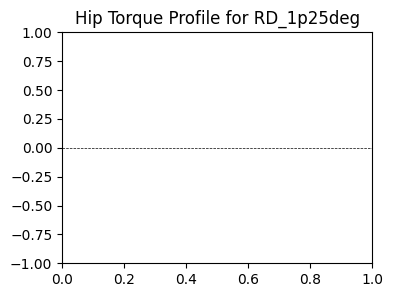

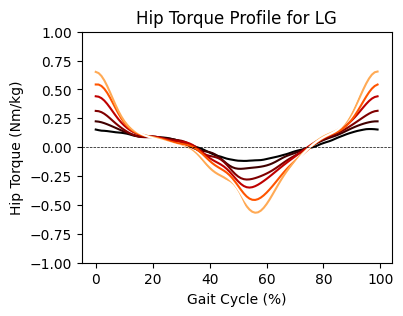

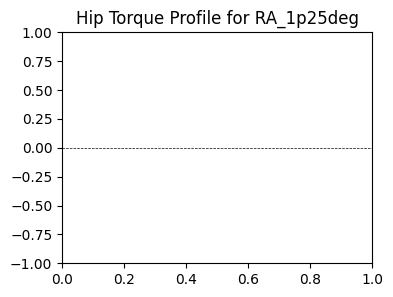

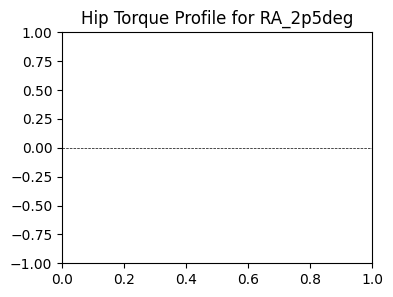

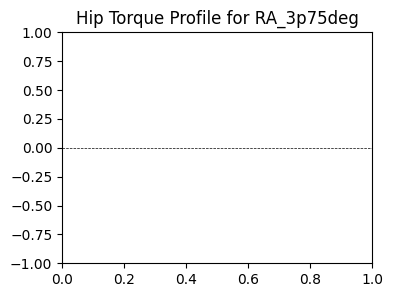

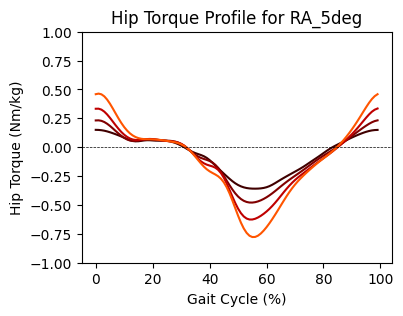

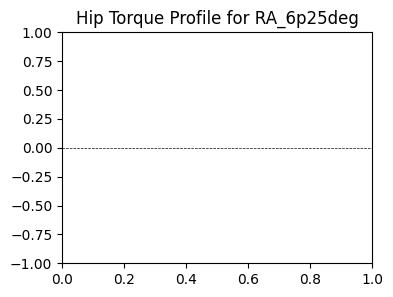

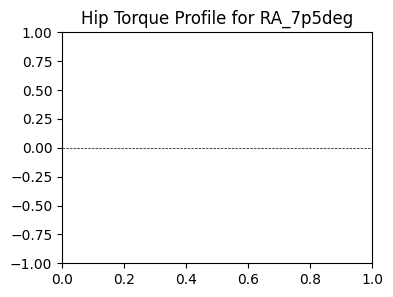

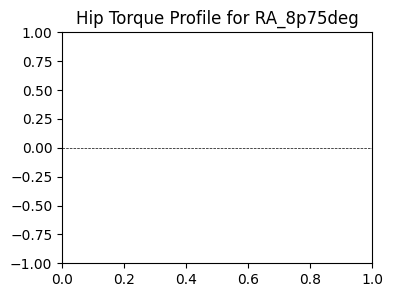

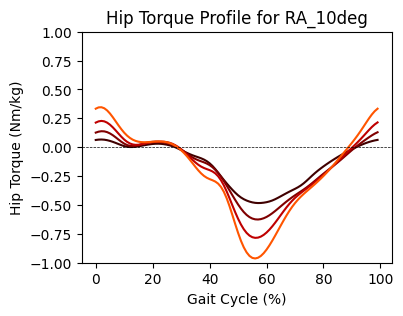

In [22]:
def interpolate_two_cycles(cycle1, cycle2, weight):
    interpolated_len = cycle1.shape[0]*weight + cycle2.shape[0]*(1-weight)
    cycle1_upsampled = upsampling(cycle1, int(interpolated_len))
    cycle2_upsampled = upsampling(cycle2, int(interpolated_len))
    interpolated_cycle = cycle1_upsampled * weight + cycle2_upsampled * (1 - weight)
    return interpolated_cycle

task_increment = 4

# Interpolate for unseen speeds and seen inclinations
for inclination in inclinations:
    for speed in speeds_unseen:

        speed_idx = speeds_all.index(speed)
        if speed_idx == 0 or speed_idx == len(speeds_all) - 1: # Skip if it's the first or last speed
            continue
        front_speed = speeds_all[(speed_idx//task_increment) * 4]
        back_speed = speeds_all[(speed_idx//task_increment + 1) * 4]
        task_weight = 1 - (speed_idx % task_increment) / task_increment

        if avg_hip_torque[inclination][front_speed] is None or avg_hip_torque[inclination][back_speed] is None:
            continue
        print(f'Interpolating for inclination: {inclination}, speed: {speed}')

        avg_hip_torque[inclination][speed] = interpolate_two_cycles(avg_hip_torque[inclination][front_speed], avg_hip_torque[inclination][back_speed], task_weight)

# Interpolate for unseen inclinations and seen speeds
for speed in speeds:
    for inclination in inclinations_unseen: 

        inclination_idx = inclinations_all.index(inclination)
        if inclination_idx == 0 or inclination_idx == len(inclinations_all) - 1: # Skip if it's the first or last inclination
            continue
        front_inclination = inclinations_all[(inclination_idx//task_increment) * 4]
        back_inclination = inclinations_all[(inclination_idx//task_increment + 1 ) * 4]
        task_weight = 1 - (inclination_idx % task_increment) / task_increment

        if avg_hip_torque[front_inclination][speed] is None or avg_hip_torque[back_inclination][speed] is None:
            continue
        print(f'Interpolating for inclination: {inclination}, speed: {speed}')

        avg_hip_torque[inclination][speed] = interpolate_two_cycles(avg_hip_torque[front_inclination][speed], avg_hip_torque[back_inclination][speed], task_weight)

# Interpolate for unseen speeds and unseen inclinations
for inclination in inclinations_unseen:
    for speed in speeds_unseen:

        speed_idx = speeds_all.index(speed)
        if speed_idx == 0 or speed_idx == len(speeds_all) - 1: # Skip if it's the first or last speed
            continue
        front_speed = speeds_all[(speed_idx//task_increment) * task_increment]
        back_speed = speeds_all[(speed_idx//task_increment + 1) * task_increment]
        task_weight = 1 - (speed_idx % task_increment) / task_increment

        if avg_hip_torque[inclination][front_speed] is None or avg_hip_torque[inclination][back_speed] is None:
            continue

        print(f'Interpolating for inclination: {inclination}, speed: {speed}')
        avg_hip_torque[inclination][speed] = interpolate_two_cycles(avg_hip_torque[inclination][front_speed], avg_hip_torque[inclination][back_speed], task_weight)


In [26]:
import matplotlib.cm as cm

# Generate a colormap
num_speeds = len(speeds_all)
colormap = cm.get_cmap('copper', num_speeds)  # You can choose other colormaps like 'jet', 'plasma', etc.

# Create a dictionary to store the color for each speed
speed_colors = {speeds_all[i]: colormap(i) for i in range(num_speeds)}

for inclination in inclinations_all:
    fig = plt.figure(figsize=(4, 3))
    for speed in speeds_all:
        if avg_hip_torque[inclination][speed] is None:   continue
        if 'RD' in inclination:
            plt.plot(avg_hip_torque[inclination][speed], label=f'{inclination}_{speed}', color=speed_colors[speed])
        else:
            plt.plot(avg_hip_torque[inclination][speed], label=f'{inclination}_{speed}', color=speed_colors[speed])
        plt.xlabel('Gait Cycle (%)')
        plt.ylabel('Hip Torque (Nm/kg)')
    # plt.legend()
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.ylim(-1, 1)
    plt.title(f'Hip Torque Profile for {inclination}')
    plt.show()

In [27]:
num_speeds = len(speeds_all)
colormap = cm.get_cmap('gist_heat', num_speeds)
speed_colors = {}
for i in range(num_speeds):
    # Get RGBA tuple (0-1 range) and convert to RGB (0-255 range)
    rgba = colormap(i)
    speed_colors[speeds_all[i]] = rgba  # Store RGBA values directly

inclinations_all_num = [-10, -8.75, -7.5, -6.25, -5, -3.75, -2.5, -1.25, 0,
                        1.25, 2.5, 3.75, 5, 6.25, 7.5, 8.75, 10]

fig = plt.figure(figsize=(6, 6)) # Increased size from (6, 6) to (8, 8)
ax = fig.add_subplot(111, projection='3d')

for i, inclination in enumerate(inclinations_all):
    for speed in speeds_all:
        if avg_hip_torque[inclination][speed] is None:
            continue
        
        z = inclinations_all_num[i]
        
        x = np.arange(len(avg_hip_torque[inclination][speed]))
        y = avg_hip_torque[inclination][speed]
        
        # Create an array of z values for each point
        z_values = np.array([z] * len(x))
        
        # Get the color for the current speed
        color = speed_colors[speed]
        
        # Plot the data, interchanging y and z_values
        ax.plot(x, z_values, y, color=color, label=f'{inclination} - {speed}')

ax.set_xlabel('Gait cycle (%)')
ax.set_zlabel('Biological joint torque (N-m)') # interchanging y and z labels
ax.set_ylabel('Inclination (deg)') # interchanging y and z labels

# Optionally, create a legend (it might be too crowded)
# ax.legend()
ax.view_init(elev=30, azim=45)  # Adjust elevation and azimuth as needed
ax.invert_xaxis()

plt.title('Biological Hip Torque Profiles Across Tasks and Speeds')
plt.tight_layout()
plt.show()


# save the torque profile

In [ ]:
import pickle

# Export avg_hip_moment as a pickle file
with open('avg_biological_hip_torque.pkl', 'wb') as f:
    pickle.dump(avg_hip_torque, f)

In [1]:
import pickle

# Load avg_hip_moment from the pickle file
with open('avg_biological_hip_torque.pkl', 'rb') as f:
    loaded_avg_hip_moment = pickle.load(f)

# Now you can use loaded_avg_hip_moment as needed
print(loaded_avg_hip_moment.keys())

print(loaded_avg_hip_moment['LG']['0p2mps'].shape)

dict_keys(['RD_10deg', 'RD_8p75deg', 'RD_7p5deg', 'RD_6p25deg', 'RD_5deg', 'RD_3p75deg', 'RD_2p5deg', 'RD_1p25deg', 'LG', 'RA_1p25deg', 'RA_2p5deg', 'RA_3p75deg', 'RA_5deg', 'RA_6p25deg', 'RA_7p5deg', 'RA_8p75deg', 'RA_10deg'])
(100,)


In [ ]:
import numpy as np

print(np.__version__)

2.2.6
